In [1]:
import sys
sys.path.append('../')
from utils_models import *

In [2]:
with open('../pickles/mesolve_temp_kappa1em3_1649_compu_see_fidelity.pkl', 'rb') as file:
    results = pickle.load(file)


In [3]:
tot_time =820
tlist = np.linspace(0, tot_time, tot_time)



num_time_steps = tot_time

zero = qutip.basis(2, 0)
one = qutip.basis(2, 1)
states_ideal  = [
                # zero,
                # one,
                (zero +  one).unit(),
                (zero - one).unit(),
                # (zero + 1j * one).unit(),
                # (zero - 1j * one).unit(),
                ]


def calc_average_fidelity_with_phase(phase,dms,states_ideal):
    gate = qutip.qip.operations.phasegate(phase)
    fid=[]
    for dm,dm_ideal in zip(dms,states_ideal):
        new_dm = gate*dm*gate.dag()
        fid.append(qutip.fidelity(new_dm, dm_ideal))
        # fid.append(qutip.fidelity(dm, gate*dm_ideal))
    return 1-sum(fid)/len(fid)


from scipy.optimize import minimize

infidelity1 = []
phase1 = []
for idx in tqdm(range(num_time_steps)):
    dms = [result.states_dressed_to_2_level_dm[idx] for result in results]
    def objective_function(phase):
        return calc_average_fidelity_with_phase(phase[0], dms, states_ideal)
    initial_phase = [0.0]
    bounds = [(0, 2 * 3.141592653589793)]
    opt_result = minimize(objective_function, initial_phase,method="COBYLA")
    infidelity1.append(opt_result.fun)
    phase1.append(opt_result.x[0])


100%|██████████| 820/820 [00:11<00:00, 70.86it/s]


Text(0.5, 0, 'ns')

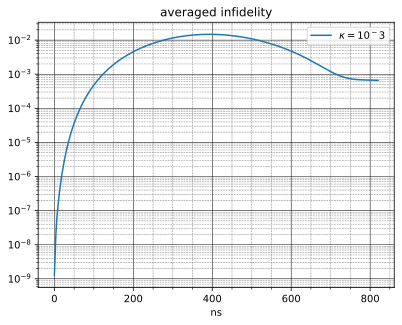

In [4]:
plt.plot(results[0].times,infidelity1,label = rf'$\kappa = 10^{-3}$')

plt.grid(which='major', linestyle='-', linewidth='0.5', color='black')
plt.minorticks_on()
plt.grid(which='minor', linestyle='--', linewidth='0.5', color='gray')

plt.legend()

plt.yscale('log')
plt.title("averaged infidelity")
plt.xlabel("ns")

(795.0, 820.0)

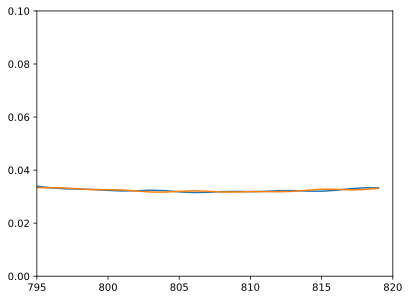

In [7]:

for result in results:
    plt.plot(result.expect[1])
plt.ylim(0,0.1)
plt.xlim(795,820)

In [2]:
max_ql = 12
max_ol = 50

system = FluxoniumOscillatorSystem(
    computaional_states = '1,2',
    EJ = 2.33,
    EC = 0.69,
    EL = 0.12,
    Er = 7.16518677,
    g_strength = 0.18,
    qubit_level = max_ql,
    osc_level = max_ol,
    products_to_keep=[[ql, ol] for ql in range(4) for ol in range(max_ol) ],
)

In [3]:
with open('../pickles/mesolve_temp_1649_see_domi_frequency.pkl', 'rb') as file:
    results = pickle.load(file)
    

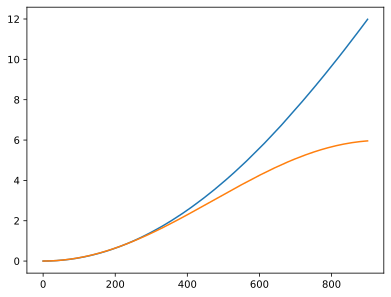

In [7]:
for result in results:
    plt.plot(result.times, result.expect[1])
# plt.xlim(799,803)
# plt.ylim(0,0.001)

In [11]:
interactive_heatmap(results[0], system.product_to_dressed, system.qbt.truncated_dim, system.osc.truncated_dim)

interactive(children=(IntSlider(value=0, continuous_update=False, description='Time Index:', max=899), Output(…

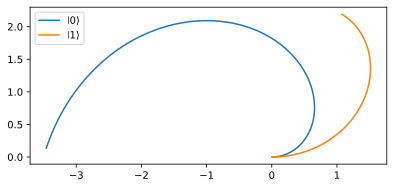

In [10]:
with open('../pickles/mesolve_temp_1649_see_domi_frequency.pkl', 'rb') as file:
    results = pickle.load(file)
eigenstate_results  = [results[0],results[1]]
tlist = results[0].times
first_dominant_freq =find_dominant_frequency(eigenstate_results[1].expect[0],tlist)
for i, result in enumerate(eigenstate_results):
    alpha = result.expect[0]*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)
    plt.plot(-alpha.imag,alpha.real,label =  rf'$\left|{i}\right>$')
plt.legend()
plt.gca().set_aspect('equal', 'box')

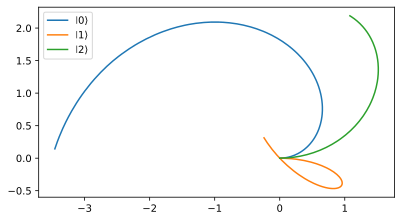

In [14]:
with open('../pickles/mesolve_temp_1649_see_domi_frequency.pkl', 'rb') as file:
    results = pickle.load(file)
eigenstate_results  = [results[0],results[1],results[2]]
tot_time = 900
tlist = np.linspace(0, tot_time, tot_time)
first_dominant_freq =find_dominant_frequency(eigenstate_results[2].expect[0],tlist)
for i, result in enumerate(eigenstate_results):
    alpha = result.expect[0]*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)
    plt.plot(-alpha.imag,alpha.real,label =  rf'$\left|{i}\right>$')
plt.legend()
plt.gca().set_aspect('equal', 'box')

(0.0, 0.001)

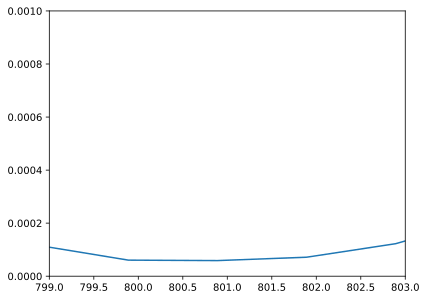

In [25]:
plt.plot(tlist, results[1].expect[1])
plt.xlim(799,803)
plt.ylim(0,0.001)

 /var/folders/yv/8f1w22v95lj4r3b_62lwrtvr0000gn/T/ipykernel_65635/2390501495.py: 41

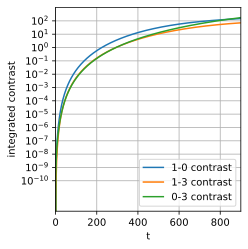

In [15]:
plt.figure(figsize=(3+3/8,3+3/8))
kappa_val = 1e-3

alpha1 = results[1].expect[-2]*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)
alpha0 = results[0].expect[-2]*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)
alpha3 = results[2].expect[-2]*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)


squared_diff = np.square(abs(alpha0-alpha1))
integrals = [0.0]
for i in range(1,len(tlist)):
    integrals.append(integrals[i-1]+
                        (tlist[i]-tlist[i-1])*np.sqrt(kappa_val)*squared_diff[i]
                        )
    
plt.plot(tlist,integrals,label='1-0 contrast')

squared_diff = np.square(abs(alpha3-alpha1))
integrals = [0.0]
for i in range(1,len(tlist)):
    integrals.append(integrals[i-1]+
                        (tlist[i]-tlist[i-1])*np.sqrt(kappa_val)*squared_diff[i]
                        )
    
plt.plot(tlist,integrals,label='1-3 contrast')


squared_diff = np.square(abs(alpha3-alpha0))
integrals = [0.0]
for i in range(1,len(tlist)):
    integrals.append(integrals[i-1]+
                        (tlist[i]-tlist[i-1])*np.sqrt(kappa_val)*squared_diff[i]
                        )
    
plt.plot(tlist,integrals,label='0-3 contrast')



plt.legend(loc='lower right')
plt.yscale('log')
plt.ylim(0,1e3)
plt.yticks([1e-10,1e-9,1e-8,1e-7,1e-6,1e-5,1e-4,1e-3,1e-2,1e-1,1,1e1,1e2])
plt.xlim(0,tot_time)
plt.grid()
plt.tight_layout()
plt.xlabel('t')
plt.ylabel('integrated contrast')
# plt.savefig("fig06_integral.pdf", format='pdf', bbox_inches='tight')
plt.show()



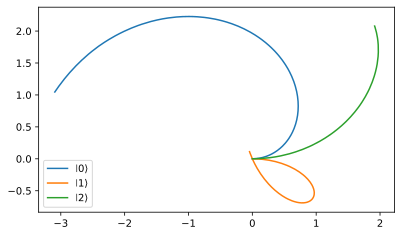

In [12]:
with open('../pickles/mesolve_temp_1650_see_domi_frequency.pkl', 'rb') as file:
    results = pickle.load(file)

eigenstate_results  = [results[0],results[1],results[2]]
tot_time = 900
tlist = np.linspace(0, tot_time, tot_time)
first_dominant_freq =find_dominant_frequency(eigenstate_results[2].expect[0],tlist)
for i, result in enumerate(eigenstate_results):
    alpha = result.expect[0]*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)
    plt.plot(-alpha.imag,alpha.real,label =  rf'$\left|{i}\right>$')
plt.legend()
plt.gca().set_aspect('equal', 'box')

 /var/folders/yv/8f1w22v95lj4r3b_62lwrtvr0000gn/T/ipykernel_65635/2390501495.py: 41

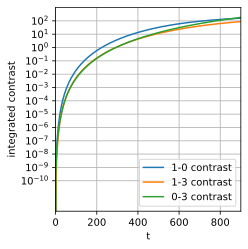

In [13]:
plt.figure(figsize=(3+3/8,3+3/8))
kappa_val = 1e-3

alpha1 = results[1].expect[-2]*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)
alpha0 = results[0].expect[-2]*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)
alpha3 = results[2].expect[-2]*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)


squared_diff = np.square(abs(alpha0-alpha1))
integrals = [0.0]
for i in range(1,len(tlist)):
    integrals.append(integrals[i-1]+
                        (tlist[i]-tlist[i-1])*np.sqrt(kappa_val)*squared_diff[i]
                        )
    
plt.plot(tlist,integrals,label='1-0 contrast')

squared_diff = np.square(abs(alpha3-alpha1))
integrals = [0.0]
for i in range(1,len(tlist)):
    integrals.append(integrals[i-1]+
                        (tlist[i]-tlist[i-1])*np.sqrt(kappa_val)*squared_diff[i]
                        )
    
plt.plot(tlist,integrals,label='1-3 contrast')


squared_diff = np.square(abs(alpha3-alpha0))
integrals = [0.0]
for i in range(1,len(tlist)):
    integrals.append(integrals[i-1]+
                        (tlist[i]-tlist[i-1])*np.sqrt(kappa_val)*squared_diff[i]
                        )
    
plt.plot(tlist,integrals,label='0-3 contrast')



plt.legend(loc='lower right')
plt.yscale('log')
plt.ylim(0,1e3)
plt.yticks([1e-10,1e-9,1e-8,1e-7,1e-6,1e-5,1e-4,1e-3,1e-2,1e-1,1,1e1,1e2])
plt.xlim(0,tot_time)
plt.grid()
plt.tight_layout()
plt.xlabel('t')
plt.ylabel('integrated contrast')
# plt.savefig("fig06_integral.pdf", format='pdf', bbox_inches='tight')
plt.show()

